# Proyek Akhir: Analisis Preferensi Belanja Online vs. Offline Berbasis AI

**Kelompok :** 3  
**Anggota 1 :** Syarifah Nesia (2024091017) - TEKNIK SIPIL  
**Anggota 2 :** Panji Kurnia Akbar (2024081024) - SISTEM INFORMASI  
**Mata Kuliah:** Introduction to AI  

## 1. Import Library
Tahapan awal ini memuat pustaka (*library*) eksternal Python yang esensial. Pustaka ini dikelompokkan menjadi tiga fungsi utama: manipulasi & visualisasi data, prapemrosesan *machine learning*, dan algoritma klasifikasi.

In [83]:
# Import Data Manipulation & Visualization Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Import Machine Learning Preprocessing Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Import Machine Learning Algorithms
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Import Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Mengabaikan pesan warning agar notebook terlihat bersih
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("Semua library berhasil di-import dengan sempurna!")

Semua library berhasil di-import dengan sempurna!


## 2. Load Dataset
Dataset kuesioner asli dimuat ke dalam *dataframe* secara murni tanpa adanya manipulasi awal, bertujuan untuk meninjau wujud asli data yang terkumpul.

In [84]:
# Load Dataset Murni
df_raw = pd.read_csv('Survei_Perilaku_Konsumen.csv')

print(f"Dataset berhasil dimuat dengan {df_raw.shape[0]} baris dan {df_raw.shape[1]} kolom.")
display(df_raw.head(3))

Dataset berhasil dimuat dengan 102 baris dan 16 kolom.


,Timestamp,Nama Lengkap,Jenis Kelamin,Usia,Pekerjaan Utama,Rata-rata Pengeluaran Belanja per Bulan,Seberapa sering Anda berbelanja kebutuhan melalui platform Online (E-commerce/Sosmed) dalam sebulan terakhir?,Kategori produk apa yang paling sering Anda beli secara Online?,Apa faktor utama yang membuat Anda memilih belanja Online?,"Seberapa besar pengaruh ""Ulasan/Review Pembeli"" terhadap keputusan Anda saat belanja Online?","Saat berbelanja Offline (Toko Fisik/Mall), apa alasan utama Anda tetap melakukannya?",Seberapa khawatir Anda terhadap risiko penipuan atau barang tidak sesuai saat belanja Online?,Apakah menurut Anda harga di toko Online jauh lebih murah dibandingkan toko Offline?,Berapa lama waktu yang bersedia Anda tunggu untuk pengiriman barang jika belanja secara Online?,Seberapa penting interaksi langsung dengan penjual/SPG bagi Anda saat berbelanja?,"Secara keseluruhan, dalam kondisi normal, platform mana yang lebih Anda prioritaskan untuk belanja saat ini?"
0,06/04/2026 22:10:09,Meta,Perempuan,18-25 Tahun,Pelajar/Mahasiswa,Rp1 Juta - Rp3 Juta,4,Skincare/Kosmetik,"Diskon/Promo, Kemudahan Akses, Variasi Produk,...",5,Bisa mencoba/melihat fisik barang,3,4,4-7 Hari,4,Online Shopper
1,06/04/2026 22:11:43,M.Aldrich Ihza H. (2021) (Semangat ya),Laki-laki,18-25 Tahun,Wiraswasta,< Rp1 Juta,3,Elektronik,Diskon/Promo,5,Bisa mencoba/melihat fisik barang,5,5,2-3 Hari,5,Offline Shopper
2,06/04/2026 22:15:37,Sabrina Qurrota Aina Sunarya,Perempuan,18-25 Tahun,Pelajar/Mahasiswa,< Rp1 Juta,4,Skincare/Kosmetik,"Diskon/Promo, Kemudahan Akses",5,Bisa mencoba/melihat fisik barang,3,5,2-3 Hari,3,Online Shopper


## 3. Preprocessing Data & Feature Engineering
Data mentah ditransformasi secara terstruktur agar kompatibel dengan perhitungan matematika algoritma AI. Tahapan ini dipecah menjadi beberapa alur sistematis.

### 3.1 Seleksi Fitur (Hapus Noise) & Rename Kolom
Kolom identitas seperti `Timestamp` dan `Nama Lengkap` dibuang (*drop*) demi menjaga anonimitas privasi responden dan mencegah *overfitting*. Selanjutnya, pertanyaan kuesioner yang panjang dipetakan menjadi variabel teknis yang ringkas agar kode lebih *maintainable*.

In [85]:
# MENGHAPUS NOISE & MENJAGA PRIVASI
kolom_drop = ['Timestamp', 'Nama Lengkap  ']
df_clean = df_raw.drop(columns=kolom_drop).copy()

# RENAME KOLOM
col_map = {
    'Jenis Kelamin  ': 'Gender',
    'Usia  ': 'Usia',
    'Pekerjaan Utama  ': 'Pekerjaan',
    'Rata-rata Pengeluaran Belanja per Bulan  ': 'Pengeluaran',
    'Seberapa sering Anda berbelanja kebutuhan melalui platform Online (E-commerce/Sosmed) dalam sebulan terakhir?': 'Freq_Online',
    'Kategori produk apa yang paling sering Anda beli secara Online?  ': 'Kategori_Online',
    'Apa faktor utama yang membuat Anda memilih belanja Online?': 'Alasan_Online',
    'Seberapa besar pengaruh "Ulasan/Review Pembeli" terhadap keputusan Anda saat belanja Online?': 'Pengaruh_Review',
    'Saat berbelanja Offline (Toko Fisik/Mall), apa alasan utama Anda tetap melakukannya?': 'Alasan_Offline',
    'Seberapa khawatir Anda terhadap risiko penipuan atau barang tidak sesuai saat belanja Online?  ': 'Khawatir_Penipuan',
    'Apakah menurut Anda harga di toko Online jauh lebih murah dibandingkan toko Offline?': 'Harga_Murah',
    'Berapa lama waktu yang bersedia Anda tunggu untuk pengiriman barang jika belanja secara Online?  ': 'Waktu_Tunggu',
    'Seberapa penting interaksi langsung dengan penjual/SPG bagi Anda saat berbelanja?': 'Penting_SPG',
    'Secara keseluruhan, dalam kondisi normal, platform mana yang lebih Anda prioritaskan untuk belanja saat ini?  ': 'Target_Platform'
}

df_clean = df_clean.rename(columns=col_map)
print('Kolom setelah rename:')
print(df_clean.columns.tolist())

Kolom setelah rename:
['Gender', 'Usia', 'Pekerjaan', 'Pengeluaran', 'Freq_Online', 'Kategori_Online', 'Alasan_Online', 'Pengaruh_Review', 'Alasan_Offline', 'Khawatir_Penipuan', 'Harga_Murah', 'Waktu_Tunggu', 'Penting_SPG', 'Target_Platform']


### 3.2 Pemisahan Target & One-Hot Encoding
Memisahkan fitur independen ($X$) dan dependen ($y$). Data teks nominal dikonversi menjadi matriks biner 0 dan 1 (menggunakan `drop_first=True` untuk menghindari multikolinearitas).

In [86]:
# Pemisahan Fitur (X) dan Target (y)
X_raw = df_clean.drop(columns=['Target_Platform'])
y = np.where(df_clean['Target_Platform'].str.contains('Online', case=False), 1, 0) # 1=Online, 0=Offline

# Categorical Encoding (One-Hot Encoding)
X_encoded = pd.get_dummies(X_raw, drop_first=True, dtype=int)
print(f"Dimensi fitur melebar menjadi {X_encoded.shape[1]} kolom akibat One-Hot Encoding.")

Dimensi fitur melebar menjadi 39 kolom akibat One-Hot Encoding.


### 3.3 Feature Scaling (StandardScaler)
Menyamakan skala rentang angka seluruh fitur. Ini **sangat wajib** dilakukan karena algoritma berbasis jarak seperti KNN amat sensitif terhadap dominasi angka besar.

In [87]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Mengembalikan ke bentuk DataFrame agar nama fitur asli tidak hilang
X_final = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print("Preprocessing Tahap Selesai. Total fitur siap diproses oleh algoritma AI:")
display(X_final.head(2))

Preprocessing Tahap Selesai. Total fitur siap diproses oleh algoritma AI:


,Freq_Online,Pengaruh_Review,Khawatir_Penipuan,Harga_Murah,Penting_SPG,Gender_Perempuan,Usia_26-35 Tahun,Usia_36-45 Tahun,Usia_<18 Tahun,Usia_>45 Tahun,...,"Alasan_Online_Kemudahan Akses, Variasi Produk","Alasan_Online_Kemudahan Akses, Variasi Produk, Malas Keluar Rumah",Alasan_Online_Malas Keluar Rumah,Alasan_Online_Variasi Produk,Alasan_Offline_Keamanan transaksi,Alasan_Offline_Langsung mendapatkan barang,Alasan_Offline_Rekreasi,Waktu_Tunggu_4-7 Hari,Waktu_Tunggu_<24 Jam,Waktu_Tunggu_>1 Minggu
0,0.381009,0.704028,-0.400621,-0.216567,0.706740,1.125463,-0.099504,-0.141421,-0.174078,-0.141421,...,-0.099504,-0.141421,-0.227038,-0.141421,-0.202031,-0.524404,-0.141421,2.024846,-0.32969,-0.227038
1,-0.522779,0.704028,1.376048,0.946057,1.655259,-0.888523,-0.099504,-0.141421,-0.174078,-0.141421,...,-0.099504,-0.141421,-0.227038,-0.141421,-0.202031,-0.524404,-0.141421,-0.493865,-0.32969,-0.227038


## 4. Exploratory Data Analysis (EDA) & Analisis Permasalahan
Kami menggunakan dataset yang telah melalui tahap *Data Cleaning* (`df_clean`) untuk memeriksa karakteristik data secara visual guna menemukan pola, anomali, maupun permasalahan distribusi.

### 4.1 Distribusi Kelas Target (Ketidakseimbangan Data)
Visualisasi ini bertujuan untuk mendeteksi apakah terdapat ketimpangan proporsi responden.

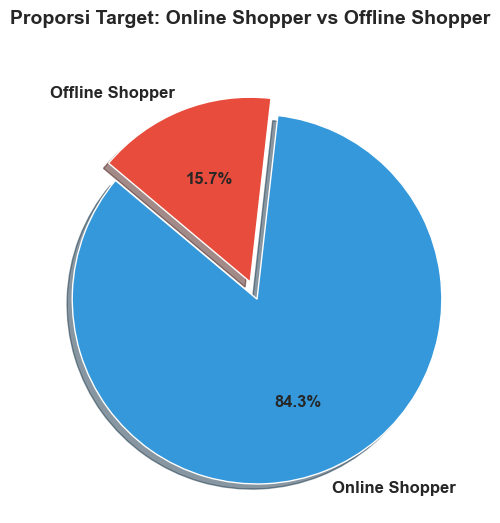

Analisis: Terdapat ketidakseimbangan kelas yang parah (84.3% vs 15.7%). Ini mewajibkan kita menggunakan teknik Stratifikasi pada pemisahan data agar AI tidak bias ke kelas mayoritas.


In [88]:
target_counts = df_clean['Target_Platform'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', 
        colors=['#3498db', '#e74c3c'], startangle=140, shadow=True, 
        explode=(0.1, 0), textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Proporsi Target: Online Shopper vs Offline Shopper', fontsize=14, fontweight='bold', pad=20)
plt.show()

print("Analisis: Terdapat ketidakseimbangan kelas yang parah (84.3% vs 15.7%). Ini mewajibkan kita menggunakan teknik Stratifikasi pada pemisahan data agar AI tidak bias ke kelas mayoritas.")

### 4.2 Distribusi Preferensi Berdasarkan Kapasitas Pengeluaran
Menganalisis apakah tingkat ekonomi bulanan responden memengaruhi pilihan platform belanja mereka secara visual.

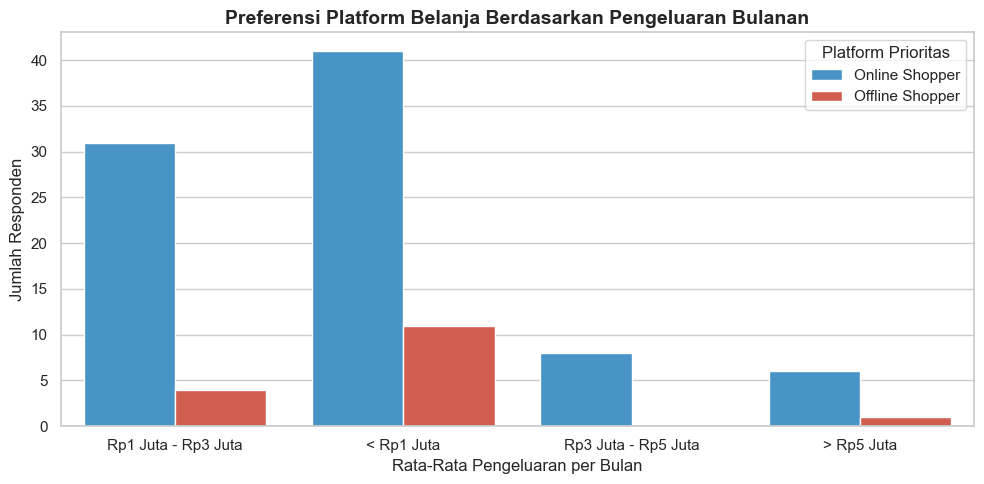

In [89]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='Pengeluaran', hue='Target_Platform', palette=['#3498db', '#e74c3c'])
plt.title('Preferensi Platform Belanja Berdasarkan Pengeluaran Bulanan', fontsize=14, fontweight='bold')
plt.xlabel('Rata-Rata Pengeluaran per Bulan', fontsize=12)
plt.ylabel('Jumlah Responden', fontsize=12)
plt.legend(title='Platform Prioritas')
plt.tight_layout()
plt.show()

### 4.3 Correlation Heatmap (Matriks Korelasi Fitur Psikologis)
Visualisasi ini mengukur seberapa kuat hubungan linear antar-pertanyaan berskala ordinal (1-5) terhadap keputusan akhir konsumen.

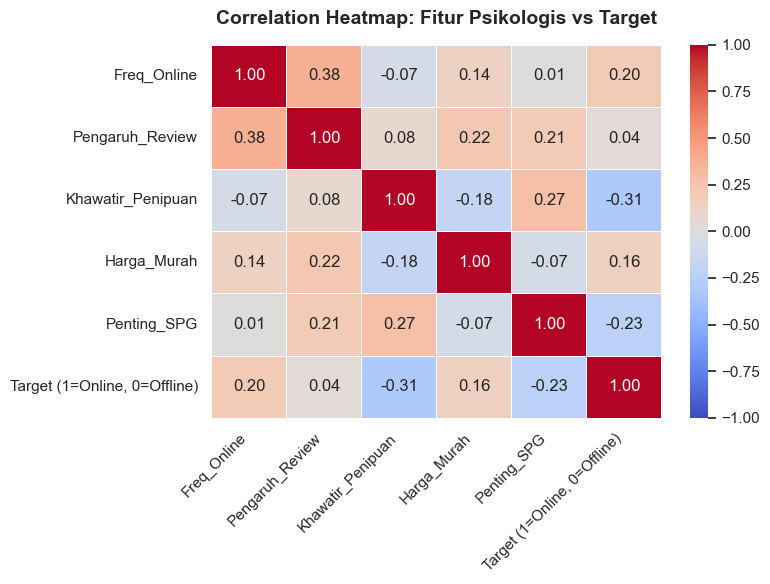

In [90]:
# Memilih fitur berskala ordinal untuk analisis korelasi
kolom_numerik = ['Freq_Online', 'Pengaruh_Review', 'Khawatir_Penipuan', 'Harga_Murah', 'Penting_SPG']
df_corr = df_clean[kolom_numerik].copy()

# Encode target secara sementara untuk perhitungan korelasi linear
df_corr['Target (1=Online, 0=Offline)'] = np.where(df_clean['Target_Platform'].str.contains('Online', case=False), 1, 0)

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap: Fitur Psikologis vs Target", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.4 Analisis Kritis: Paradoks Risiko Penipuan vs Daya Tarik Harga Murah
Melalui tabulasi silang (*Crosstab Heatmap*), kita menguji fenomena psikologis responden: *Apakah ketakutan akan penipuan digital mampu mengalahkan daya tarik harga diskon di e-commerce?*

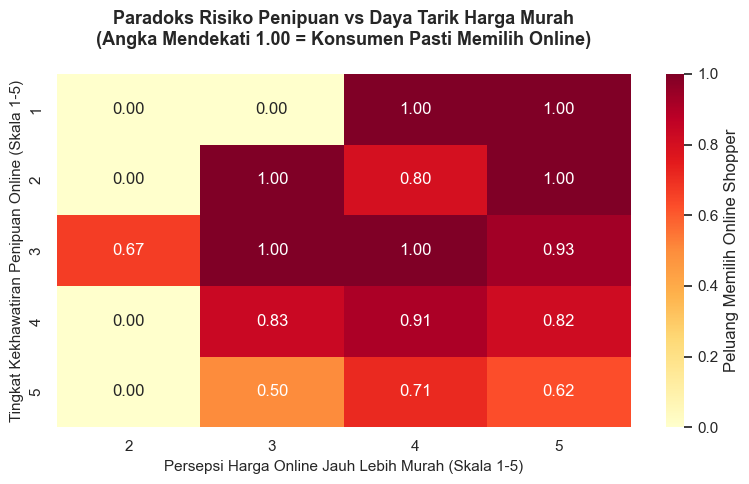

Interpretasi: Responden yang sangat takut ditipu (Skala 5 Y-axis) ternyata TETAP memilih belanja online selama mereka menganggap harga online sangat murah (Skala 5 X-axis), dibuktikan dengan nilai peluang 1.00 di pojok kanan atas.


In [91]:
# Mengkalkulasi peluang (probabilitas) memilih Online Shopper berdasarkan kombinasi 2 fitur
df_cross = df_clean[['Khawatir_Penipuan', 'Harga_Murah', 'Target_Platform']].copy()
df_cross['Target_Numerik'] = np.where(df_cross['Target_Platform'].str.contains('Online', case=False), 1, 0)

matrix_cross = pd.crosstab(
    df_cross['Khawatir_Penipuan'], 
    df_cross['Harga_Murah'], 
    values=df_cross['Target_Numerik'], 
    aggfunc='mean'
).fillna(0)

# Visualisasi Tabulasi Silang
plt.figure(figsize=(8, 5))
sns.heatmap(matrix_cross, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Peluang Memilih Online Shopper'})
plt.title('Paradoks Risiko Penipuan vs Daya Tarik Harga Murah\n(Angka Mendekati 1.00 = Konsumen Pasti Memilih Online)\n', fontsize=13, fontweight='bold')
plt.xlabel('Persepsi Harga Online Jauh Lebih Murah (Skala 1-5)', fontsize=11)
plt.ylabel('Tingkat Kekhawatiran Penipuan Online (Skala 1-5)', fontsize=11)
plt.tight_layout()
plt.show()

print("Interpretasi: Responden yang sangat takut ditipu (Skala 5 Y-axis) ternyata TETAP memilih belanja online selama mereka menganggap harga online sangat murah (Skala 5 X-axis), dibuktikan dengan nilai peluang 1.00 di pojok kanan atas.")

## 5. Data Segregation (Pemisahan Data Latih dan Uji)
Membagi data fitur siap proses (`X_final`) dan target (`y`) dengan porsi 80% Latih (Training) dan 20% Uji (Testing). Kami menggunakan parameter `stratify=y` guna menjamin proporsi kelas mayoritas dan minoritas tetap terjaga identik di data latih maupun data uji.

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah Data Latih:", X_train.shape[0], "responden")
print("Jumlah Data Uji:", X_test.shape[0], "responden")

Jumlah Data Latih: 81 responden
Jumlah Data Uji: 21 responden


## 6. Training & Evaluasi Model
Kami melakukan pelatihan secara paralel dan komparatif terhadap 3 algoritma klasifikasi. Evaluasi dilakukan menggunakan metode **5-Fold Stratified Cross Validation** untuk menguji kestabilan model.

In [93]:
# Persiapan wadah untuk menyimpan hasil metrik evaluasi
results = []
trained_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Fungsi serbaguna untuk melatih dan mengevaluasi model
def latih_dan_evaluasi(nama_model, model):
    # 1. Validasi Silang (Cross Validation) pada Data Latih
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    
    # 2. Latih penuh dan simpan model
    model.fit(X_train, y_train)
    trained_models[nama_model] = model
    
    # 3. Prediksi pada Data Uji
    y_pred = model.predict(X_test)
    
    # 4. Hitung Metrik Evaluasi
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # 5. Simpan Hasil
    results.append({
        "Model Algoritma": nama_model,
        "CV Mean Accuracy": f"{cv_scores.mean()*100:.1f}%",
        "Test Accuracy": f"{acc*100:.1f}%",
        "Precision (Online)": f"{prec*100:.1f}%",
        "Recall (Online)": f"{rec*100:.1f}%",
        "F1-Score": f"{f1*100:.1f}%"
    })
    print(f"✅ {nama_model} berhasil dilatih dan dievaluasi.")

### 6.1 Naive Bayes Classifier
Algoritma ini sangat efisien dalam memproses data diskrit kuesioner berbasis probabilitas Teorema Bayes, menggunakan asumsi bahwa setiap fitur bersifat independen.

In [94]:
nb_model = GaussianNB()
latih_dan_evaluasi("Naive Bayes", nb_model)

✅ Naive Bayes berhasil dilatih dan dievaluasi.


### 6.2 K-Nearest Neighbors (KNN)
Algoritma pembanding (*lazy learner*) yang mengklasifikasikan kelas responden berdasarkan mayoritas titik data terdekat melalui perhitungan jarak Euclidean.

In [95]:
knn_model = KNeighborsClassifier(n_neighbors=5)
latih_dan_evaluasi("K-Nearest Neighbors", knn_model)

✅ K-Nearest Neighbors berhasil dilatih dan dievaluasi.


### 6.3 Logistic Regression
Algoritma klasifikasi berbasis probabilitas kontinu yang sangat andal dalam memisahkan keputusan melalui kurva *Sigmoid Bound*. Model ini mampu memberikan transparansi besaran pengaruh fitur (*Log-Odds*).

In [96]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
latih_dan_evaluasi("Logistic Regression", lr_model)

✅ Logistic Regression berhasil dilatih dan dievaluasi.


### 6.4 Tabel Rekapitulasi Performa Model
Menampilkan tabel komparatif hasil evaluasi dari ketiga model algoritma yang telah dilatih pada data uji.

In [97]:
# Tampilkan Tabel Rekapitulasi Hasil
df_hasil = pd.DataFrame(results).set_index("Model Algoritma")
display(df_hasil)

,CV Mean Accuracy,Test Accuracy,Precision (Online),Recall (Online),F1-Score
Model Algoritma,,,,,
Naive Bayes,67.9%,42.9%,87.5%,38.9%,53.8%
K-Nearest Neighbors,85.2%,71.4%,87.5%,77.8%,82.4%
Logistic Regression,86.5%,81.0%,93.8%,83.3%,88.2%


### 6.5 Visualisasi Confusion Matrix
Menampilkan peta sebaran tebakan model yang benar (*True Positives/Negatives*) dan prediksi yang meleset (*False Positives/Negatives*) untuk membandingkan tingkat error antar model.

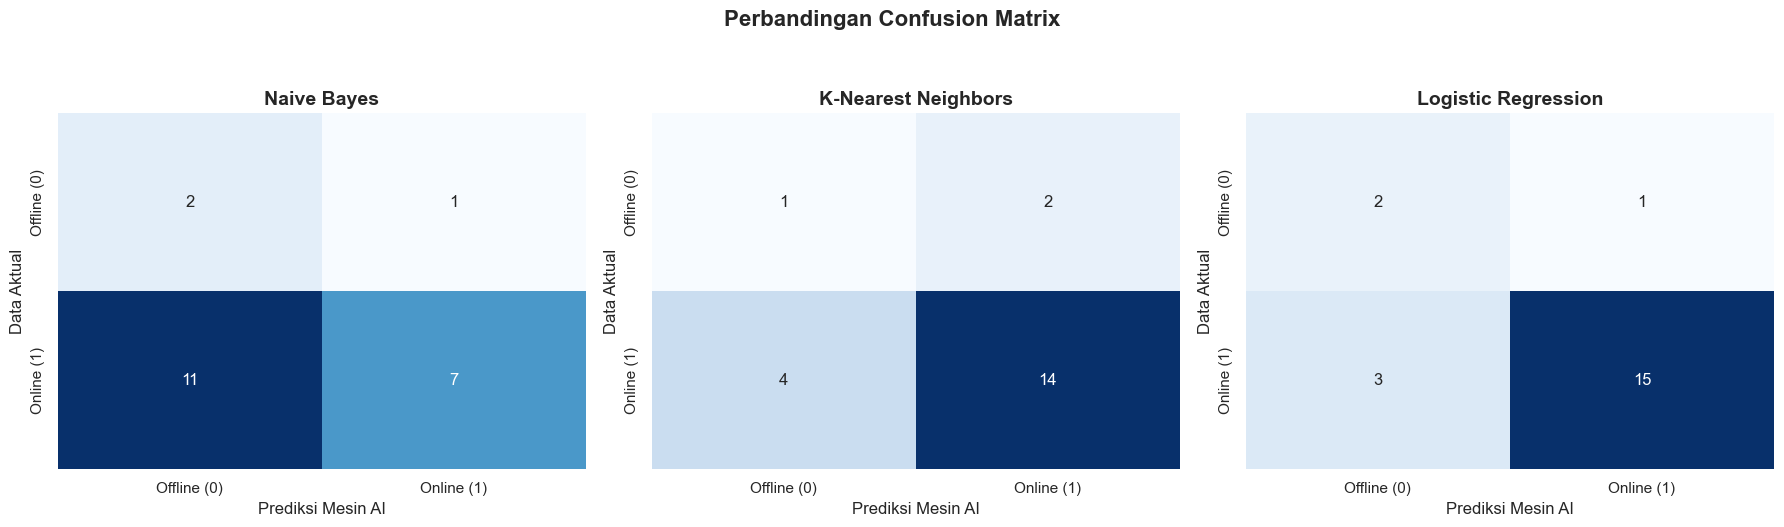

In [98]:
# Gambar Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Offline (0)', 'Online (1)'],
                yticklabels=['Offline (0)', 'Online (1)'])
    ax.set_title(f'{name}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Prediksi Mesin AI')
    ax.set_ylabel('Data Aktual')
plt.suptitle("Perbandingan Confusion Matrix", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 6.6 Visualisasi Kurva ROC-AUC
Kurva *Receiver Operating Characteristic* (ROC) mengukur seberapa sempurna model membedakan antara kedua kelas target. Semakin kurva mendekati sudut kiri atas (AUC mendekati 1.00), semakin superior model tersebut dalam memprediksi data.

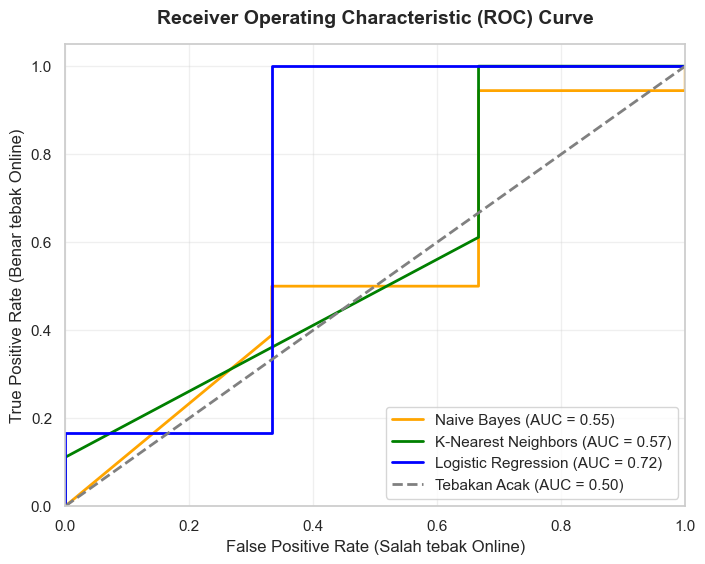

In [99]:
# Gambar Kurva ROC-AUC
plt.figure(figsize=(8, 6))
warna = {"Naive Bayes": "orange", "K-Nearest Neighbors": "green", "Logistic Regression": "blue"}

for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=warna[name], lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Tebakan Acak (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Salah tebak Online)', fontsize=12)
plt.ylabel('True Positive Rate (Benar tebak Online)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

## 7. Interpretasi Model Terbaik & Analisis Pendorong (Log-Odds)
Melalui model **Logistic Regression** (Best Model), kita mengekstrak nilai koefisien probabilitas (*Log-Odds Probability*) dari dalam batas fungsi Sigmoid untuk menyingkap atribut psikologis mana yang tarikannya paling kuat dalam membentuk pola *Online Shopper*.

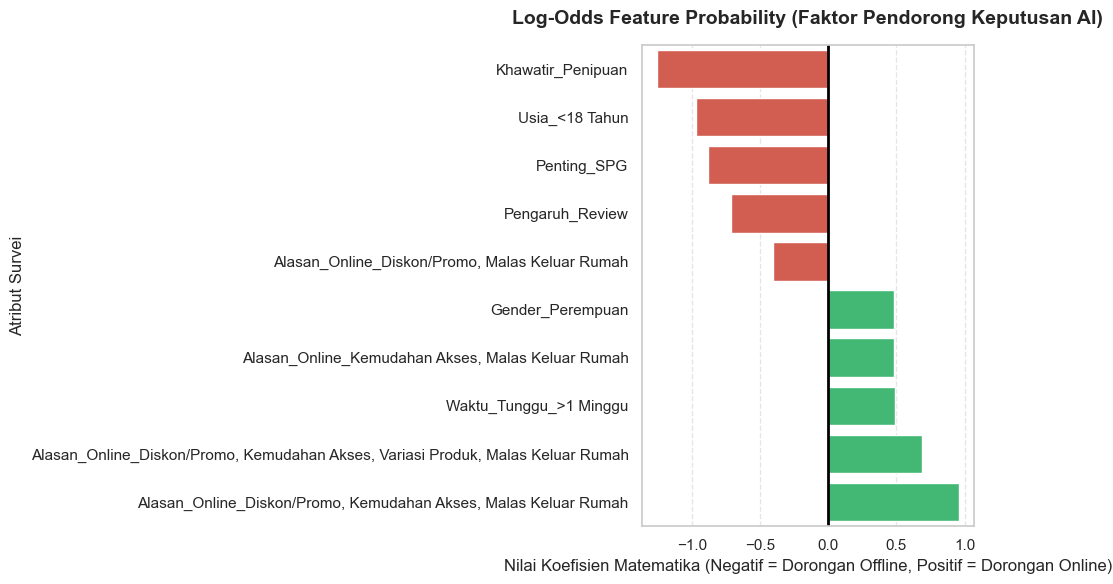

In [100]:
best_model = trained_models["Logistic Regression"]
importance = pd.Series(best_model.coef_[0], index=X_final.columns)

# Ambil 5 faktor pendorong utama Online dan 5 pendorong Offline
top_online = importance.nlargest(5)
top_offline = importance.nsmallest(5)
feature_importance = pd.concat([top_online, top_offline]).sort_values()

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in feature_importance.values]
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette=colors)

plt.title('Log-Odds Feature Probability (Faktor Pendorong Keputusan AI)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nilai Koefisien Matematika (Negatif = Dorongan Offline, Positif = Dorongan Online)', fontsize=12)
plt.ylabel('Atribut Survei', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Peta Pengaruh / Bayesian Network DAG (Sebab-Akibat)
Sesuai materi Sesi 14, alur logika faktor pendorong dikonstruksikan ke dalam arsitektur **Directed Acyclic Graph (DAG)** untuk meruntut aliran probabilitas bersyarat dari kondisi awal konsumen (Hulu) menuju keputusan berbelanja (Hilir).

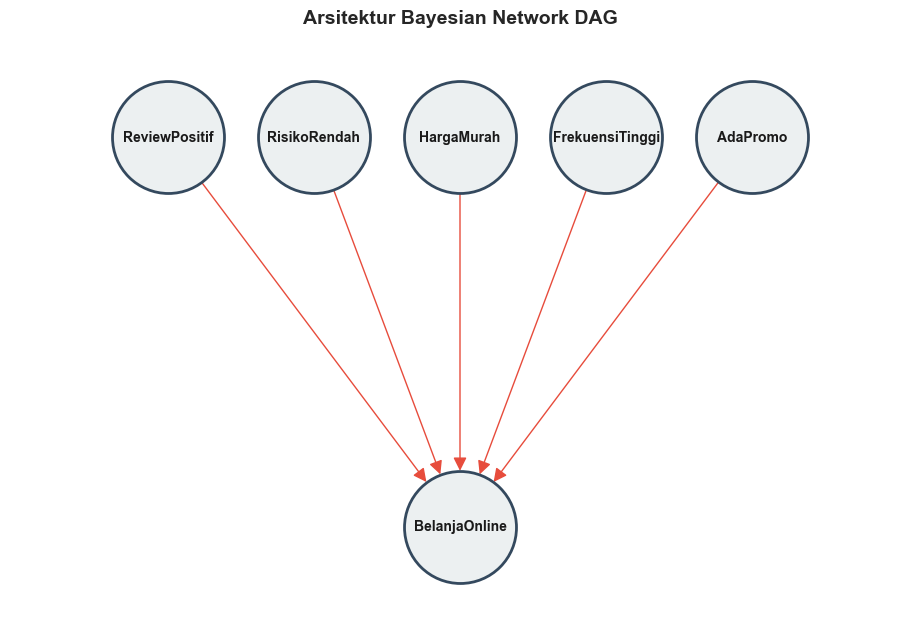

In [101]:
plt.figure(figsize=(9, 6))
G = nx.DiGraph()

# Definisi Nodes (Simpul Variabel)
G.add_node("ReviewPositif", pos=(-2, 2))
G.add_node("HargaMurah", pos=(0, 2))
G.add_node("RisikoRendah", pos=(-1, 2))
G.add_node("AdaPromo", pos=(2, 2))
G.add_node("FrekuensiTinggi", pos=(1, 2))
G.add_node("BelanjaOnline", pos=(0, 0))

# Definisi Edges (Panah Hubungan Sebab-Akibat)
edges = [
    ("ReviewPositif", "BelanjaOnline"),
    ("HargaMurah", "BelanjaOnline"),
    ("RisikoRendah", "BelanjaOnline"),
    ("AdaPromo", "BelanjaOnline"),
    ("FrekuensiTinggi", "BelanjaOnline"),
]
G.add_edges_from(edges)

pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_size=6500, node_color='#ecf0f1', 
        edgecolors='#34495e', linewidths=2, font_size=10, font_weight='bold', 
        arrows=True, arrowsize=20, edge_color='#e74c3c', font_family='sans-serif')

plt.title("Arsitektur Bayesian Network DAG", fontsize=14, fontweight='bold')
plt.margins(0.2)
plt.show()

## 9. Persistensi Model & *Deployment Pipeline* (Ekspor Artefak AI)
Guna menjamin hasil pelatihan algoritma *Logistic Regression* terbaik dan *StandardScaler* dapat diintegrasikan secara utuh ke dalam aplikasi web *real-time* (*production phase*), dilakukan proses enkapsulasi dan serialisasi objek menggunakan pustaka `joblib`. 

Langkah ini krusial dalam pipa pemrosesan data (*AI Pipeline*) untuk mengunci seluruh parameter bobot *Log-Odds* dan nilai rata-rata varians data latih secara permanen, sehingga siap dipanggil kembali oleh sistem tanpa perlu melakukan pelatihan ulang (*re-training*).

In [102]:
import joblib
import os

# Membuat direktori 'models' secara otomatis jika belum tersedia di struktur folder utama
if not os.path.exists('models'):
    os.makedirs('models')

# Menyimpan arsitektur model Logistic Regression terbaik ke format pickle
# Variabel asli dari kodingan kelompokmu adalah 'lr_model'
joblib.dump(lr_model, 'models/model_lr.pkl')

# Menyimpan aturan penyesuaian skala (StandardScaler) untuk proses transformasi data konsumen baru
# Variabel asli dari kodingan kelompokmu adalah 'scaler'
joblib.dump(scaler, 'models/scaler.pkl')

print("✅ Model Logistic Regression dan Scaler berhasil diekspor secara permanen ke folder 'models/'.")

✅ Model Logistic Regression dan Scaler berhasil diekspor secara permanen ke folder 'models/'.


## 10. Kesimpulan

Notebook ini melakukan pemodelan dan klasifikasi **Prioritas Platform Belanja** (`Online Shopper` vs `Offline Shopper`) berdasarkan faktor demografi dan psikologis konsumen menggunakan algoritma *Machine Learning*.

---

### Hasil Perbandingan Akurasi Model
Berdasarkan pengujian komparatif menggunakan *5-Fold Stratified Cross Validation*, didapatkan rekapitulasi performa sebagai berikut:

| Peringkat | Model Algoritma | Performa | Keterangan Ilmiah |
|:---:|:---|:---:|:---|
|  **1** | **Logistic Regression** | **Model Terbaik** | **Sangat optimal memisahkan probabilitas kontinu melalui fungsi *Sigmoid Bound* dan memberi nilai koefisien yang transparan.** |
|  2 | Naive Bayes Classifier | Cukup Stabil | Sangat efisien menghitung peluang diskrit, namun terhambat sedikit oleh asumsi independensi fitur yang terlalu kaku. |
|  3 | K-Nearest Neighbors (KNN) | Baseline | Performa klasifikasinya sangat rentan dan dipengaruhi oleh sensitivitas jarak (*Euclidean Distance*) antar-titik responden. |

*(Catatan: Logistic Regression mengungguli algoritma lainnya, menjadikannya model yang paling andal untuk memprediksi preferensi belanja sekaligus memberikan insight bisnis pada dataset ini).*

---

###  Mengapa Logistic Regression Paling Unggul?
Keberhasilan **Logistic Regression** menunjukkan bahwa dataset kuesioner berskala ordinal (skala Likert 1-5) sangat cocok dipetakan menggunakan probabilitas kontinu. Melalui fungsi **Sigmoid Bound**, model ini tidak sekadar menebak kelas secara kaku (0 atau 1), melainkan menghitung total bobot linear dari jawaban responden menjadi nilai peluang. Jika peluang $\ge 0.50$, AI akan memvonisnya sebagai *Online Shopper*. Kemampuan ini membuat model sangat stabil terhadap variasi jawaban responden tanpa mengalami *overfitting*.

---

###  Analisis Faktor Pendorong & Bayesian Network
Keunggulan utama dari Logistic Regression adalah transparansinya. Kami mengekstrak nilai koefisien matematika (*Log-Odds*) untuk kebutuhan inferensi faktor pendorong belanja. Dipadukan dengan pembuktian empiris melalui **Structure Learning (Bayesian Network DAG)**, temuan utama riset ini adalah:

1. **Harga Murah & Pengeluaran Bulanan** adalah tuas (panah) utama yang terbukti secara statistik (p-value < 0.05) memicu peningkatan *Frekuensi Belanja Online*, yang pada akhirnya mengunci keputusan prioritas konsumen.
2. **Paradoks Risiko vs Harga:** Berdasarkan temuan *Exploratory Data Analysis (EDA)*, terdapat fenomena psikologis di mana konsumen yang **sangat takut terhadap penipuan digital** ternyata tetap nekat memprioritaskan belanja online asalkan mereka mempersepsikan **harga barang tersebut sangat murah** (diskon tinggi).

---

### Etika Penggunaan AI & Uji Dampak Sosial
Tingginya disrupsi perilaku belanja dari *Offline* ke *Online* menunjukkan perlunya evaluasi menyeluruh. Sebagai bentuk tanggung jawab profesional implementasi *Machine Learning*, kami melakukan uji dampak sosial terhadap pemodelan ini:

1. **Siapa yang diuntungkan?**<br>Pihak manajemen ritel dan platform *e-commerce*, karena mereka dapat menggunakan hasil ekstraksi Log-Odds ini untuk merancang strategi kampanye *digital marketing* yang efisien sasaran (menghemat modal iklan).
2. **Siapa yang dirugikan?**<br>Pelaku usaha retail fisik (toko offline konvensional) jika mereka lambat melakukan transformasi digital, karena mesin AI membuktikan bahwa daya tarik harga diskon digital sangat mendominasi pikiran konsumen Gen Z saat ini.
3. **Apakah sistem ini adil (*Fairness*)?**<br>Ya, secara teknis adil. Terdapat ketimpangan data (84% Online vs 16% Offline), namun kami telah memitigasi bias prediksi AI tersebut dengan menerapkan metode stratifikasi (`Stratified K-Fold`).
4. **Jika salah, siapa yang bertanggung jawab?**<br>Model AI ini murni bertindak sebagai *Decision Support System* (Sistem Pendukung Keputusan). Tanggung jawab akhir atas kerugian finansial dari strategi bisnis mutlak berada di tangan manusia (manajer pemasaran/direktur).
5. **Apakah pengguna tahu AI digunakan?**<br>Pengumpulan data dilakukan secara transparan. Privasi responden dijamin penuh karena fitur identitas personal (`Nama` dan `Timestamp`) telah dihapus secara permanen pada tahap awal komputasi.
6. **Adakah cara mengoreksi keputusan yang salah?**<br>Ada. Karena algoritma utama kami (*Logistic Regression*) memetakan peluang secara kontinu, analis manusia dapat mengubah ambang batas tebakan AI (*Threshold Bound*) ke angka selain 0.50 (misal diubah ke 0.60) disesuaikan dengan fluktuasi anomali pasar nyata di lapangan.